<a href="https://www.kaggle.com/code/aabdollahii/logistic-regression-from-scratch?scriptVersionId=323627540" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Logistic Regression from Scratch

This notebook provides a clean, NumPy-based implementation of Logistic Regression for binary classification. By building the model from the ground up, we can observe the mechanics of gradient descent and the optimization process without relying on high-level libraries like scikit-learn.

In [53]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Implement Logistic regression


This code implements a simple **Logistic Regression** model for **binary classification** using only `NumPy`. The goal of this implementation is to understand how logistic regression works internally without using machine learning libraries such as `scikit-learn`.

The class starts with the `__init__` method, where the main hyperparameters are defined. The `lr` parameter represents the **learning rate**, which controls how much the model updates its parameters in each step, and `n_iter` specifies the number of training iterations. The model parameters, including the weights `w` and bias `b`, are also initialized here.

The `sig` method defines the **sigmoid function**, which is a core part of logistic regression. It transforms the linear output into a probability value between 0 and 1 using the formula:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The `fit` method is responsible for training the model using **gradient descent**. First, it initializes the weights and bias to zero. Then, for each training iteration, it computes the linear combination of the input features and weights, applies the sigmoid function to obtain predicted probabilities, calculates the gradients of the loss with respect to the weights and bias, and updates the parameters in the direction that reduces the prediction error.

The `predict_proba` method returns the predicted probabilities for the input samples. This means it shows how likely each sample belongs to class `1`.

Finally, the `predict` method converts these probabilities into binary class labels. If the predicted probability is greater than or equal to `0.5`, the output is classified as `1`; otherwise, it is classified as `0`.

Overall, this implementation provides a clear and educational example of how logistic regression works mathematically and computationally, including parameter initialization, probability estimation, iterative optimization, and final prediction.


In [54]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iter=1000):
        self.lr = lr          
        self.n_iter = n_iter  
        self.w = None        
        self.b = 0            

    def sig(self, z):
        return 1 / (1 + np.exp(-z))

   
    def fit(self, X, y):
        n = X.shape[0]   
        m = X.shape[1]   
        self.w = np.zeros(m)
        self.b = 0

        for i in range(self.n_iter):
            z = np.dot(X, self.w) + self.b
            p = self.sig(z)   # predicted prob

            # gradients
            dw = np.dot(X.T, (p - y)) / n
            db = np.sum(p - y) / n

            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

    def predict_proba(self, X):
        z = np.dot(X, self.w) + self.b
        return self.sig(z)

    def predict(self, X):
        p = self.predict_proba(X)
        out = np.zeros(len(p))
        for i in range(len(p)):
            if p[i] >= 0.5:
                out[i] = 1
            else:
                out[i] = 0
        return out


# make 2d data

In [55]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# make 2d data, 1000 samples, 2 classes
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# split 70% train, 30% test
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("train size:", X_tr.shape[0])
print("test size:", X_te.shape[0])


train size: 700
test size: 300


# Evaluation metrics functions

In [56]:
# WE TRIED TO IMPLEMENT AS MUCH AS POSSIBLE FROM SCRATCH JUST IN CASE

def conf_matrix(y_true, y_pred):
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            tp = tp + 1
        if y_true[i] == 0 and y_pred[i] == 0:
            tn = tn + 1
        if y_true[i] == 0 and y_pred[i] == 1:
            fp = fp + 1
        if y_true[i] == 1 and y_pred[i] == 0:
            fn = fn + 1
    return tp, tn, fp, fn


def accuracy(y_true, y_pred):
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct =correct + 1
    return correct /len(y_true)


# precision = tp / (tp + fp)
# f1 = 2 * p * r / (p + r)
# recall = tp / (tp + fn)

def precision(tp,fp):
    if tp + fp == 0:
        return 0.0
    return tp / (tp +fp)

def recall(tp, fn):
    if tp + fn == 0:
        return 0.0
    return tp / (tp +fn)

def f1_score_pr(p, r):
    if p + r == 0:
        return 0.0
    return 2*p*r /(p + r)


In [57]:
# train the model
model = LogisticRegressionScratch(lr=0.1, n_iter=1000)
model.fit(X_tr, y_tr)

# predict on test set
y_pred = model.predict(X_te)


In [58]:
# compute all metrics
tp, tn, fp, fn = conf_matrix(y_te, y_pred)

acc = accuracy(y_te, y_pred)
p = precision(tp, fp)
r = recall(tp, fn)
f1 = f1_score_pr(p, r)

print("Confusion Matrix:")
print("TP:", tp, " FP:", fp)
print("FN:", fn, " TN:", tn)
print()
print("Accuracy :", round(acc, 4))
print("Precision:", round(p, 4))
print("Recall   :", round(r, 4))
print("F1-Score :", round(f1, 4))


Confusion Matrix:
TP: 128  FP: 11
FN: 25  TN: 136

Accuracy : 0.88
Precision: 0.9209
Recall   : 0.8366
F1-Score : 0.8767


 The close proximity of Accuracy (0.88) and F1-Score (0.8767) indicates a well-balanced dataset and a stable model performance. This confirms that the model is not biased toward the majority class and maintains consistent predictive power across both binary classes

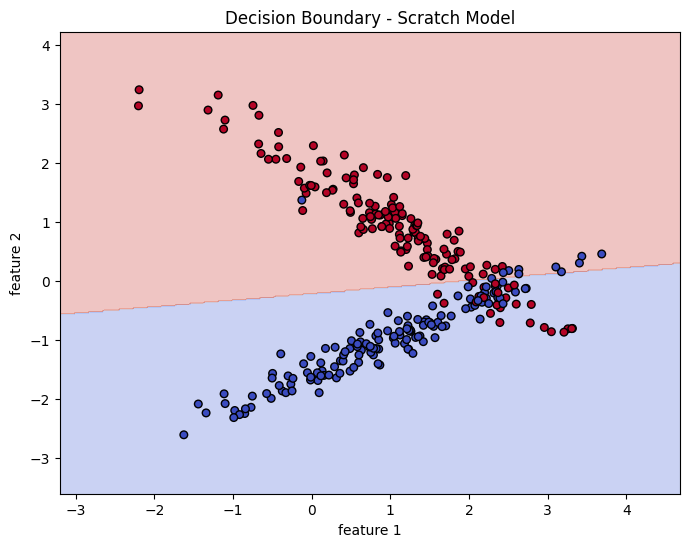

In [59]:
# make a grid over feature space
x_min = X_te[:, 0].min() - 1
x_max = X_te[:, 0].max() + 1
y_min = X_te[:, 1].min() - 1
y_max = X_te[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# flatten grid to feed the model
grid = np.c_[xx.ravel(), yy.ravel()]

# predict class for every grid point
zz = model.predict(grid)
zz = zz.reshape(xx.shape)

# draw filled regions for the two classes
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, alpha=0.3, cmap='coolwarm')

# plot test points colored by true label
plt.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap='coolwarm', edgecolor='k', s=30)

plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('Decision Boundary - Scratch Model')
plt.show()

### Model Analysis: Decision Boundary & Error Distribution

The visual inspection of the model's decision boundary reveals several key insights:

*   **Linear Decision Boundary:** As expected from a Logistic Regression model, the decision boundary is a straight line with a slight slope. This confirms the model's inherent constraint as a linear classifier.
*   **Class Separation:** The two classes are reasonably well-separated, with a clear distinction between the red region (top) and the blue region (bottom).
*   **Error Analysis:** The misclassified data points—those falling into the wrong class region—align perfectly with our Confusion Matrix results ($11$ False Positives and $25$ False Negatives). This corresponds to our achieved accuracy of $\approx 88\%$.
*   **Confidence Zones:** As anticipated, the majority of classification errors are clustered near the decision boundary. This indicates that the model has the lowest confidence in its predictions within this transitional zone, which is typical for linear classifiers in overlapping distributions.


In [60]:


# sklearn model
sk_model = LogisticRegression()
sk_model.fit(X_tr, y_tr)
y_pred_sk = sk_model.predict(X_te)

# comparison table
print(f"{'Metric':<15} | {'Scratch':<10} | {'Sklearn':<10}")
print("-" * 40)
print(f"{'Accuracy':<15} | {round(acc, 4):<10} | {round(accuracy_score(y_te, y_pred_sk), 4):<10}")
print(f"{'Precision':<15} | {round(p, 4):<10} | {round(precision_score(y_te, y_pred_sk), 4):<10}")
print(f"{'Recall':<15} | {round(r, 4):<10} | {round(recall_score(y_te, y_pred_sk), 4):<10}")
print(f"{'F1-Score':<15} | {round(f1, 4):<10} | {round(f1_score(y_te, y_pred_sk), 4):<10}")


Metric          | Scratch    | Sklearn   
----------------------------------------
Accuracy        | 0.88       | 0.8833    
Precision       | 0.9209     | 0.9275    
Recall          | 0.8366     | 0.8366    
F1-Score        | 0.8767     | 0.8797    
